# NEX-GDDP Comparison
In this notebook compare the same historical and ssp245 simulations downscaled through our approach and the one resulting from the NEX-GDDP approach. While our training datasets differ (NEX-GDDP used the Princeton Global Forcing Dataset and we used ERA5), and we have slight methods differences, the comparison will still help contextualize how the datasets stack up and support confidence-building in the dataset's implementation.

Some hypotheses:
- The biases between the datasets should track roughly with biases in the underlying forcing datasets (as outlined in [issue #168](https://github.com/carbonplan/srm-downscaling/issues/168))
- The deltas between the historical and future time periods in the two datasets should look roughly similar (CP_downscaled_future - CP_downscaled_historical ~= NEX_downscaled_future - NEX_downscaled_historical ~= raw_future - raw_historical) because the climate change signal should drive the differences.
- Comparing an individual timeseries from individual pixel should have the same daily sequence of events (even if they're offset/biased).

This notebook looks at:
- maps of different metrics
- timeseries for a set of individual locations to see pixel-level timeseries
- CDFs of individual locations to assess pixel-level performance

In [37]:
%load_ext autoreload
%autoreload 2
import icechunk
import matplotlib.pyplot as plt
import xarray as xr

from srm import catalog
from srm.utils import lon_to_180
from srm.plotting import (
    calculate_statistic_to_plot,
    locations,
    plot_4regions_comparisons,
    plot_comparisons,
    plot_timeseries,
    prep_datasets_for_seasonal_cycle_plotting,
    random_non_leap_year,
sel_point
)
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def icechunk_storage(path: str):
    """Create icechunk Storage from an S3 or local path."""
    if path.startswith("s3://"):
        path_no_scheme = path[len("s3://") :]
        bucket, _, prefix = path_no_scheme.partition("/")
        return icechunk.s3_storage(bucket=bucket, prefix=prefix)
    else:
        return icechunk.local_filesystem_storage(path=path)

In [3]:
def open_from_icechunk(path: str) -> xr.Dataset:
    """Open a dataset from an icechunk store."""
    storage = icechunk_storage(path)
    icechunk.Repository.open(storage)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    return xr.open_dataset(session.store, engine="zarr", consolidated=False)

In [4]:
era5 = catalog.get("ERA5").to_xarray()
era5 = era5[['tas']]

In [42]:
# historical
cp_historical = open_from_icechunk(
    "s3://carbonplan-scratch/srm/outputs/qa/pr-186-39db5bb-nonparametric_hybrid/historical/CESM2-WACCM/tas/r3i1p1f1/global/5e6b6f6c/historical.icechunk"
)
cp_ssp245 = open_from_icechunk(
    "s3://carbonplan-scratch/srm/outputs/qa/pr-186-39db5bb-nonparametric_hybrid/ssp245/CESM2-WACCM/tas/r3i1p1f1/global/5e6b6f6c/ssp245.icechunk"
)
nex = catalog.get("NASA-NEX-historical").to_xarray().sel(ensemble_member='r3i1p1f1').drop_vars('ensemble_member')
nex_ssp245 = catalog.get("NASA-NEX-SSP245").to_xarray().sel(ensemble_member='r3i1p1f1').drop_vars('ensemble_member')

/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [22]:
training_period = slice("1978-01-01", "2014-12-31")

In [23]:
ensemble_member = 'r3i1p1f1'
raw = catalog.get('CESM2-WACCM-historical-icechunk').to_xarray()[['tas']]#.sel(ensemble_member=ensemble_member)

In [24]:
# Maps
raw_toplot, era5_toplot, cp_toplot, nex_toplot = calculate_statistic_to_plot(
    raw.sel(time=training_period),
    era5.sel(time=training_period),
    cp_historical.sel(time=training_period),
    "mean",
    "tas",
    ds2=nex.sel(time=training_period))

In [25]:
# the latitudes don't perfectly match 

In [26]:
nex_toplot = lon_to_180(nex_toplot)

In [27]:
era5_toplot = era5_toplot.interp(coords={coord: nex_toplot[coord] for coord in nex_toplot.coords})
cp_toplot = cp_toplot.interp(coords={coord: nex_toplot[coord] for coord in nex_toplot.coords})

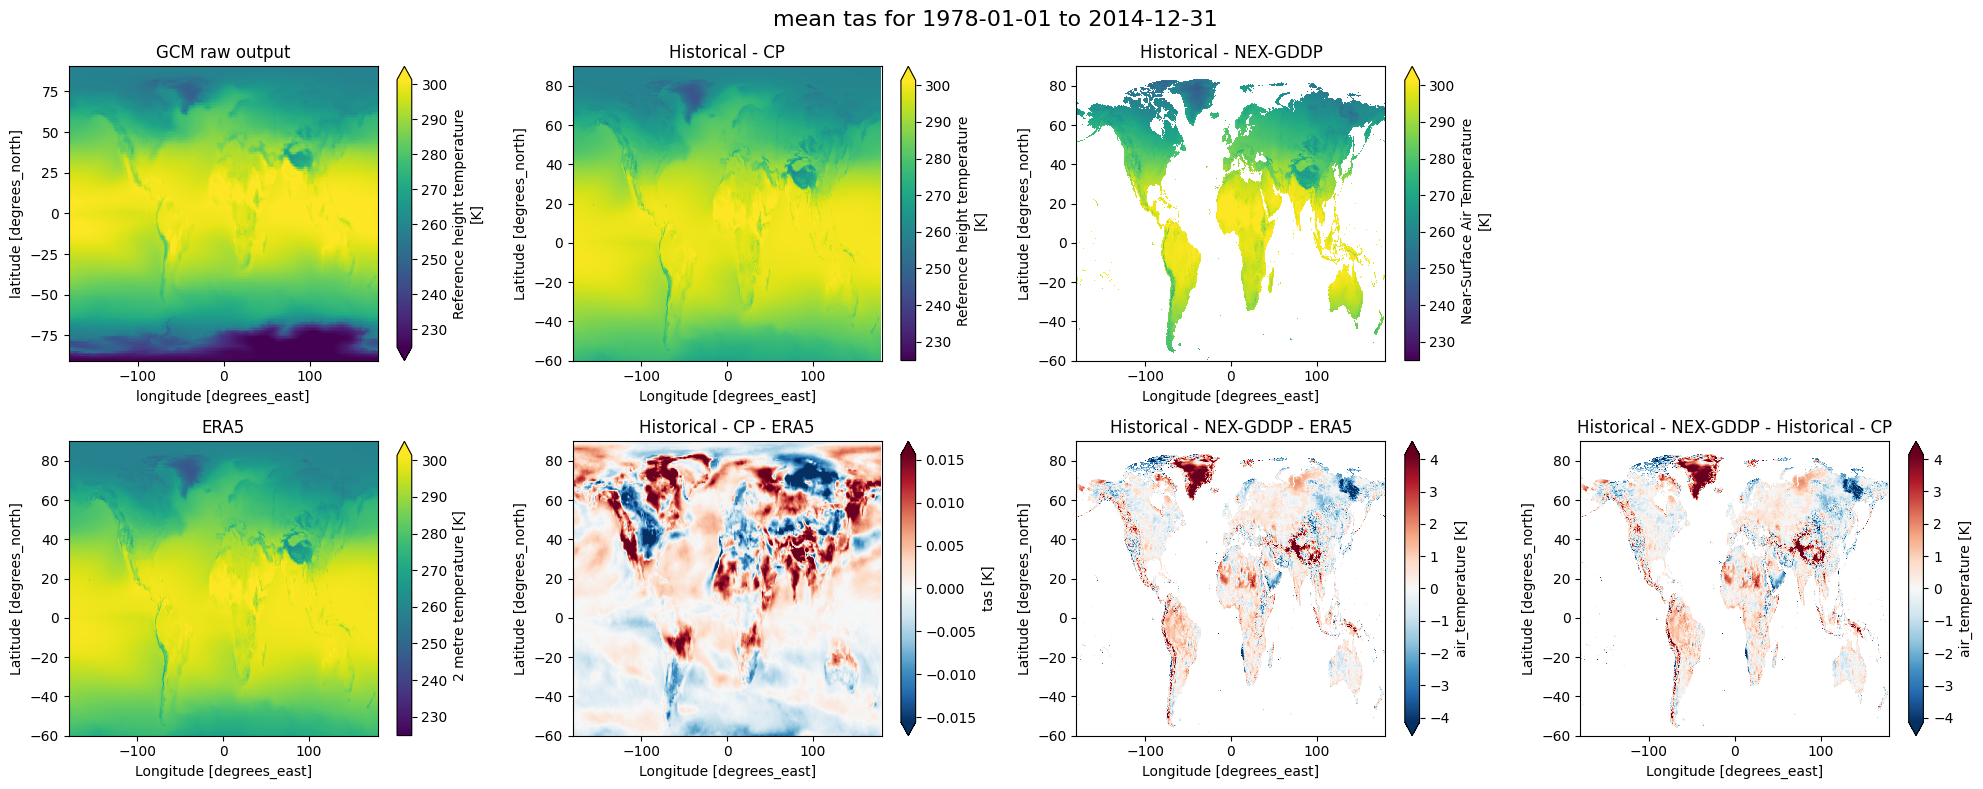

In [28]:
plot_comparisons(
    era5_toplot,
    raw_toplot,
    cp_toplot,
    ds1_name="Historical - CP",
    title=f"mean tas for {training_period.start} to {training_period.stop}",
    bias='absolute',
    ds2=nex_toplot,
ds2_name="Historical - NEX-GDDP"
)

In [ ]:
# Timeseries individual locations

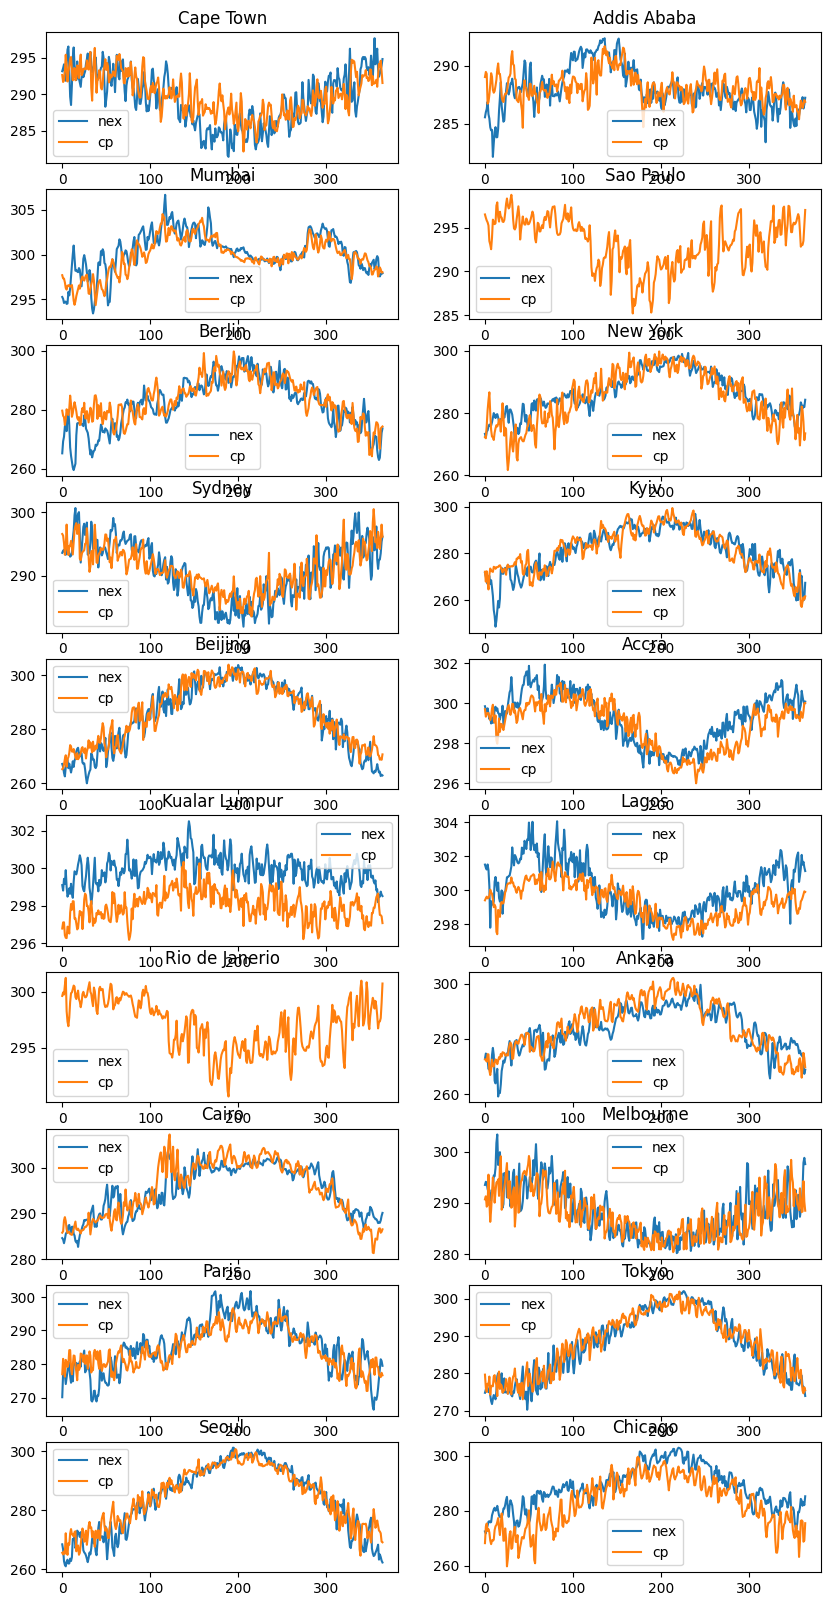

In [57]:
fig, axarr = plt.subplots(nrows=10, ncols=2, figsize=(10,20))
for i, (location, (lat, lon)) in enumerate(locations.items()):
    nex_point = sel_point(nex, lat, lon).sel(time=slice('1990', '1990'))
    cp_point = sel_point(cp_historical, lat, lon).sel(time=slice('1990', '1990'))
    df = pd.DataFrame()
    df['nex'] = nex_point.tas.values
    df['cp'] = cp_point.tas.values
    df.plot(ax=axarr.flatten()[i])
    axarr.flatten()[i].set_title(location)

<Axes: >

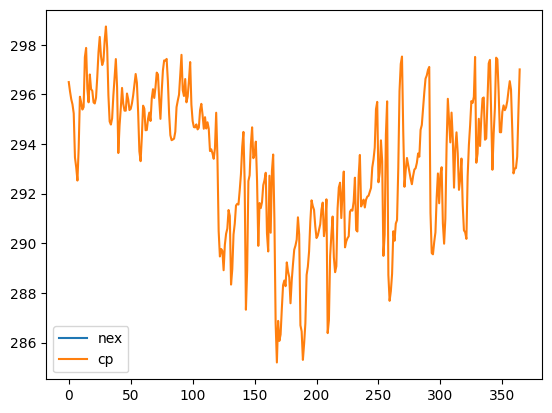

In [54]:
lat, lon = locations['Sao Paulo']
nex_point = sel_point(nex, lat, lon).sel(time=slice('1990', '1990'))
cp_point = sel_point(cp_historical, lat, lon).sel(time=slice('1990', '1990'))
df = pd.DataFrame()
df['nex'] = nex_point.tas.values
df['cp'] = cp_point.tas.values
df.plot()

In [ ]:
# CDFs